# (08) New Implementation: working?

host: ```yoru```, device: ```cuda:1```

**motivation:** <br>
The new implementation works?

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## 64 = 32 (x 2)  . . .  beta = 64.0

- t_train = 64
- t_tbptt = 32
- beta = 64.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 64
cfg_mod['t_tbptt'] = 32
cfg_mod['beta_outer'] = 64.0

# cfg_tr['batch_size'] = 200
# cfg_tr['epochs'] = 10

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

154500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-64[§32]_b-64_k-[512]_u-10,du-10
b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:1',
       dtype=torch.int32)

In [7]:
tr.train()

epoch # 300, avg loss: 190.291: 100%|█████| 300/300 [16:22:19<00:00, 196.46s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([ 47,  56,  67,  80,  94, 111, 128, 147, 164, 181, 197, 210, 222, 231,
        239, 246, 251, 255, 258, 260, 262, 263, 264, 265, 265, 266, 266, 266,
        266, 266, 266, 267, 267, 267, 267, 267, 267, 267, 267, 267, 266, 266,
        266, 266, 266, 266, 266, 266, 266, 266, 266, 266, 266, 266, 266, 266,
        266, 266, 266, 266, 266, 266, 266, 266], device='cuda:1',
       dtype=torch.int32)

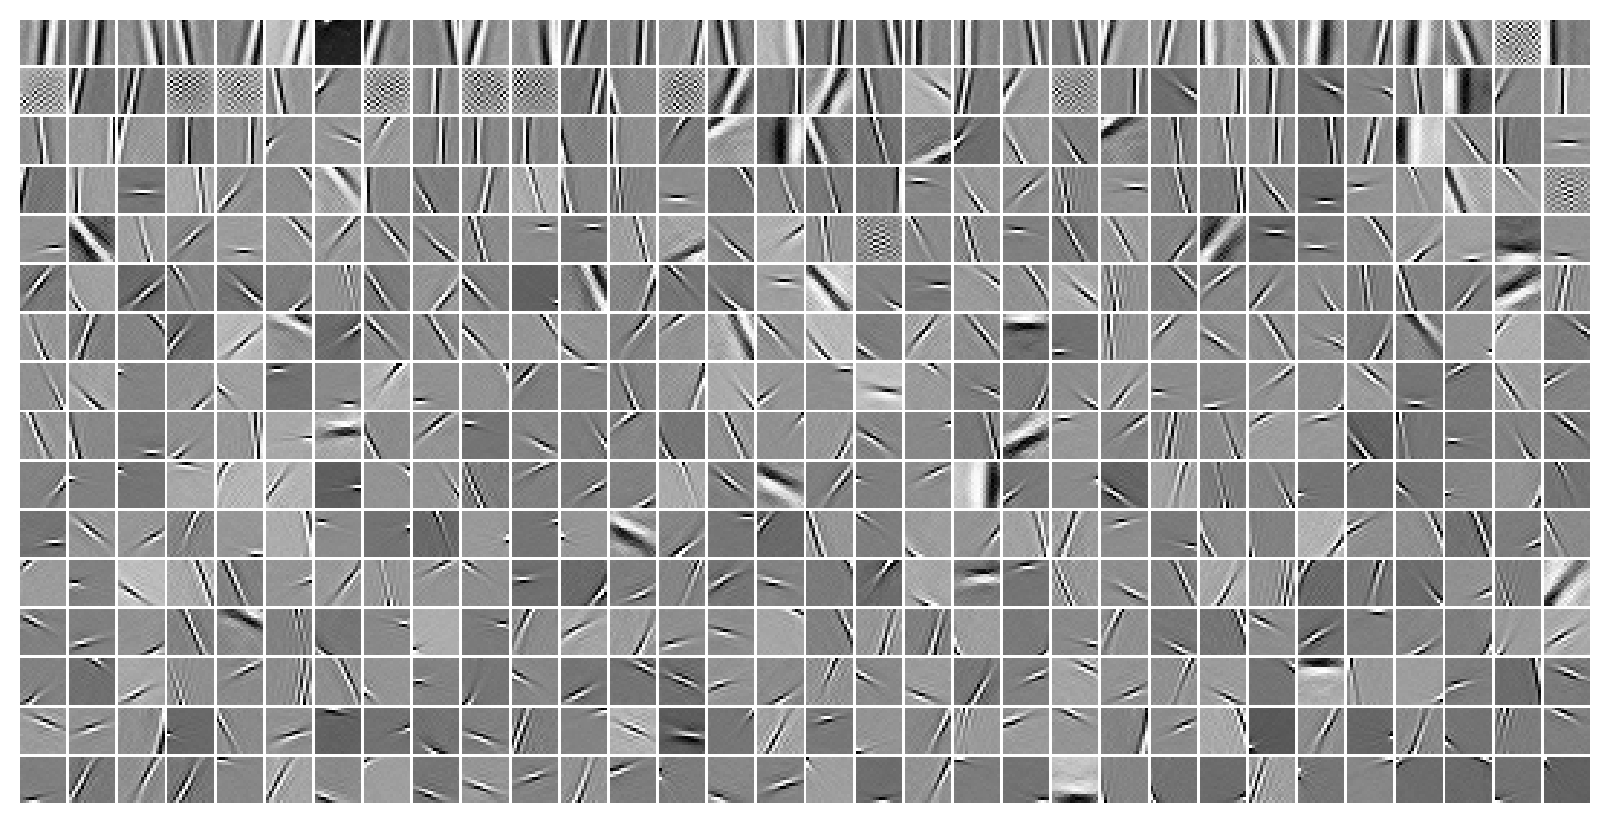

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 507.10it/s]


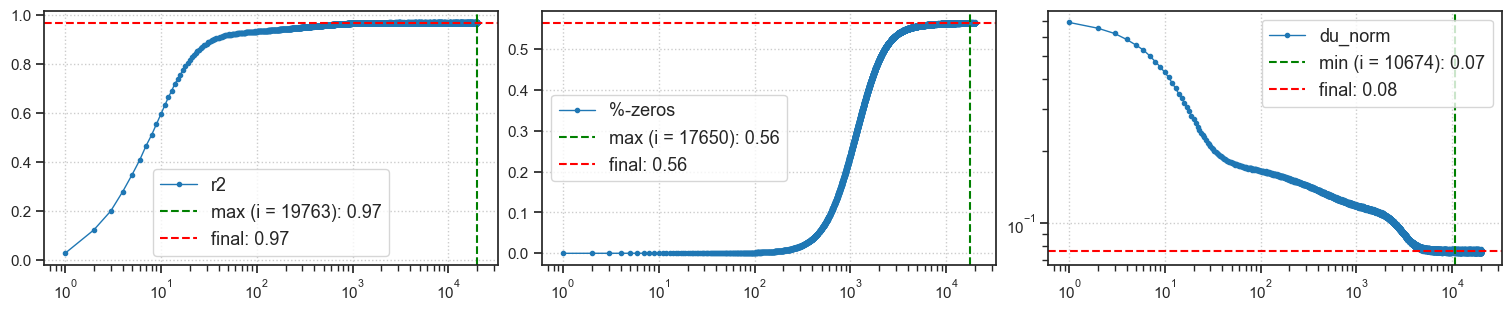

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

## 512 = 16 (x 32)  . . .  beta = 24.0

- t_train = 256
- t_tbptt = 16
- beta = 24.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 512
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 24.0

# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 10

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

5150

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-512[§16]_b-24_k-[512]_u-10,du-10
b200-ep10-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10], device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 10, avg loss: 253.433: 100%|████████| 10/10 [6:48:54<00:00, 2453.49s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([699, 748, 773, 779, 774, 761, 744, 725, 705, 685, 666, 648, 630, 613,
        598, 583, 564, 547, 533, 520, 508, 498, 488, 478, 470, 462, 454, 447,
        440, 434, 428, 423, 417, 412, 407, 403, 398, 394, 390, 386, 383, 379,
        376, 373, 370, 367, 364, 361, 358, 355, 352, 350, 347, 345, 342, 340,
        338, 336, 333, 331, 329, 327, 325, 323, 321, 319, 317, 316, 314, 312,
        310, 308, 307, 305, 304, 302, 301, 299, 298, 296, 295, 294, 292, 291,
        290, 288, 287, 286, 285, 284, 283, 282, 280, 279, 278, 277, 276, 275,
        274, 273, 272, 271, 270, 269, 268, 267, 266, 265, 264, 263, 263, 262,
        261, 260, 259, 259, 258, 257, 256, 255, 255, 254, 253, 253, 252, 251,
        251, 250, 250, 249, 248, 248, 247, 246, 246, 245, 245, 244, 244, 243,
        242, 242, 241, 241, 240, 240, 239, 239, 238, 238, 237, 237, 236, 236,
        235, 235, 235, 234, 234, 233, 233, 233, 232, 232, 231, 231, 230, 230,
        230, 229, 229, 229, 228, 228, 228, 227, 227, 226, 226, 226, 226, 225,
        225, 225, 224, 224, 224, 223, 223, 223, 222, 222, 222, 221, 221, 221,
        221, 220, 220, 220, 220, 219, 219, 219, 219, 218, 218, 218, 218, 217,
        217, 217, 217, 216, 216, 216, 216, 216, 215, 215, 215, 215, 214, 214,
        214, 214, 214, 214, 213, 213, 213, 213, 213, 212, 212, 212, 212, 212,
        212, 212, 211, 211, 211, 211, 211, 210, 210, 210, 210, 210, 210, 210,
        209, 209, 209, 209, 209, 209, 209, 209, 208, 208, 208, 208, 208, 208,
        208, 208, 207, 207, 207, 207, 207, 207, 207, 207, 206, 206, 206, 206,
        206, 206, 206, 206, 206, 205, 205, 205, 205, 205, 205, 205, 205, 205,
        204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 203,
        203, 203, 203, 203, 203, 203, 203, 203, 203, 203, 203, 203, 202, 202,
        202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202,
        201, 201, 201, 201, 201, 201, 201, 201, 201, 201, 201, 201, 201, 201,
        201, 201, 201, 201, 201, 201, 201, 201, 201, 200, 200, 200, 200, 200,
        200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
        200, 200, 200, 200, 200, 200, 200, 200, 200, 199, 199, 199, 199, 199,
        199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199,
        199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199, 199,
        199, 199, 199, 199, 199, 199, 199, 199, 199, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198,
        198, 198, 198, 198, 198, 198, 198, 198], device='cuda:1',
       dtype=torch.int32)

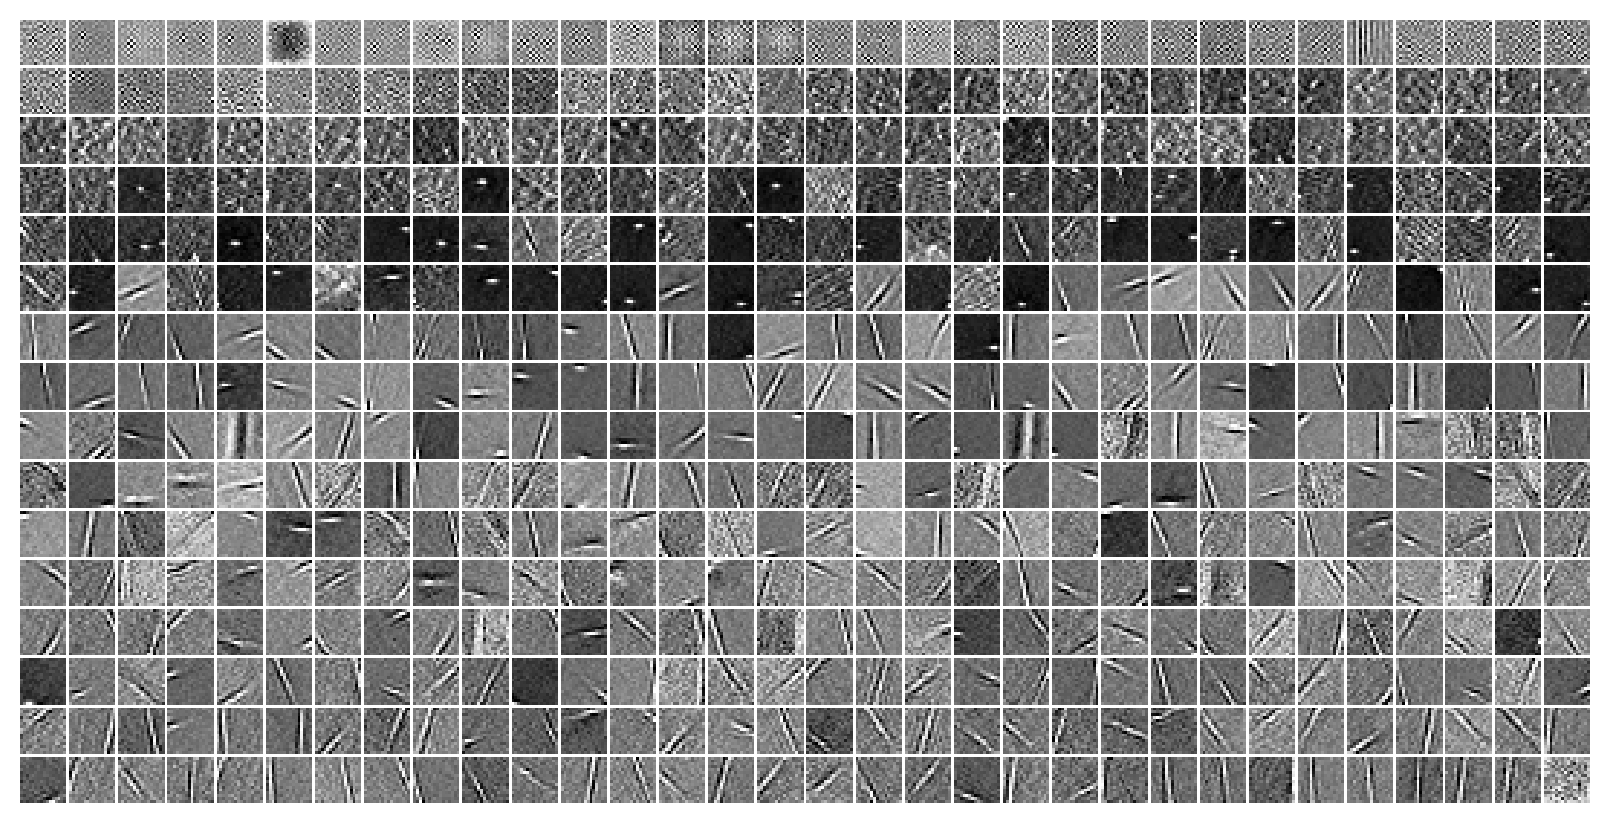

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 510.80it/s]


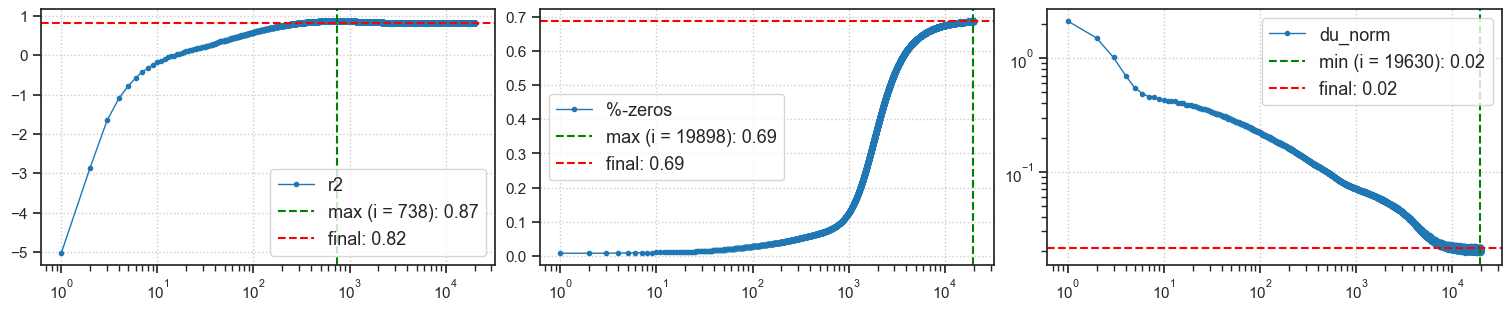

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

## 16  . . .  beta = 24.0

- t_train = 16
- t_tbptt = 16
- beta = 24.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 16
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 24.0

# cfg_tr['batch_size'] = 200
# cfg_tr['epochs'] = 300

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

154500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-16_b-24_k-[512]_u-10,du-10
b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 300, avg loss: 281.116: 100%|███████| 300/300 [2:27:29<00:00, 29.50s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([ 36,  47,  58,  70,  81,  90,  98, 102, 106, 108, 109, 109, 110, 110,
        110, 111], device='cuda:1', dtype=torch.int32)

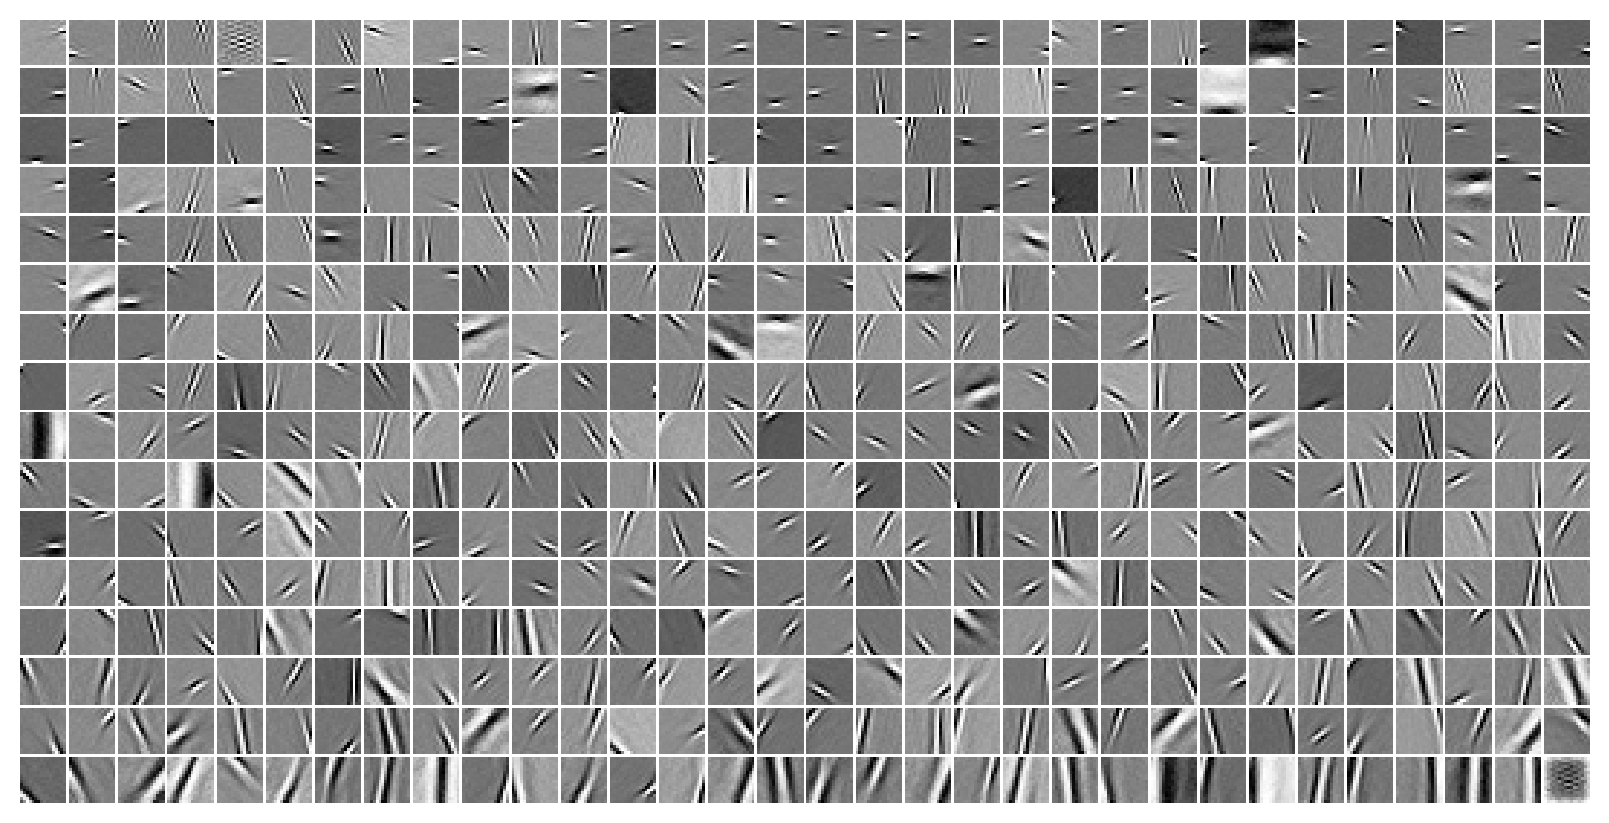

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 505.38it/s]


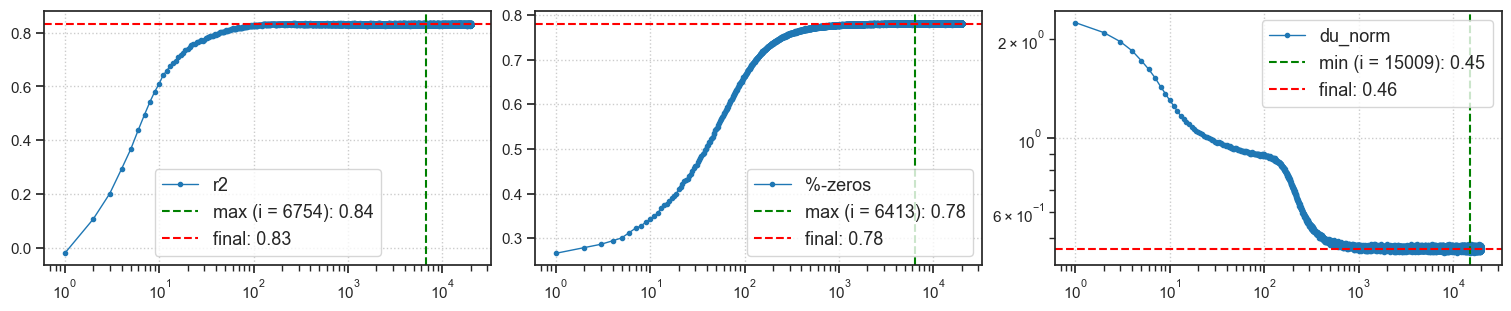

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

## 32 = 16 § 2  . . .  beta = 128.0

- t_train = 32
- t_tbptt = 16
- beta = 128.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 32
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 128.0

# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 100

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

51500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-32[§16]_b-128_k-[512]_u-10,du-10
b200-ep100-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 100, avg loss: 307.129: 100%|███████| 100/100 [1:51:49<00:00, 67.10s/it]


epoch # 100, avg loss: 228.421: 100%|███████| 100/100 [2:25:17<00:00, 87.18s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([ 60,  63,  66,  68,  71,  74,  76,  79,  82,  84,  87,  90,  92,  95,
         97, 100, 102, 105, 107, 109, 111, 113, 115, 117, 119, 121, 122, 124,
        125, 127, 128, 129], device='cuda:1', dtype=torch.int32)

In [10]:
### Was: beta = 32.0

tensor([ 40,  47,  57,  68,  80,  93, 107, 119, 131, 142, 151, 158, 164, 169,
        172, 175, 177, 179, 180, 180, 181, 182, 182, 183, 183, 183, 183, 183,
        183, 183, 183, 183], device='cuda:1', dtype=torch.int32)

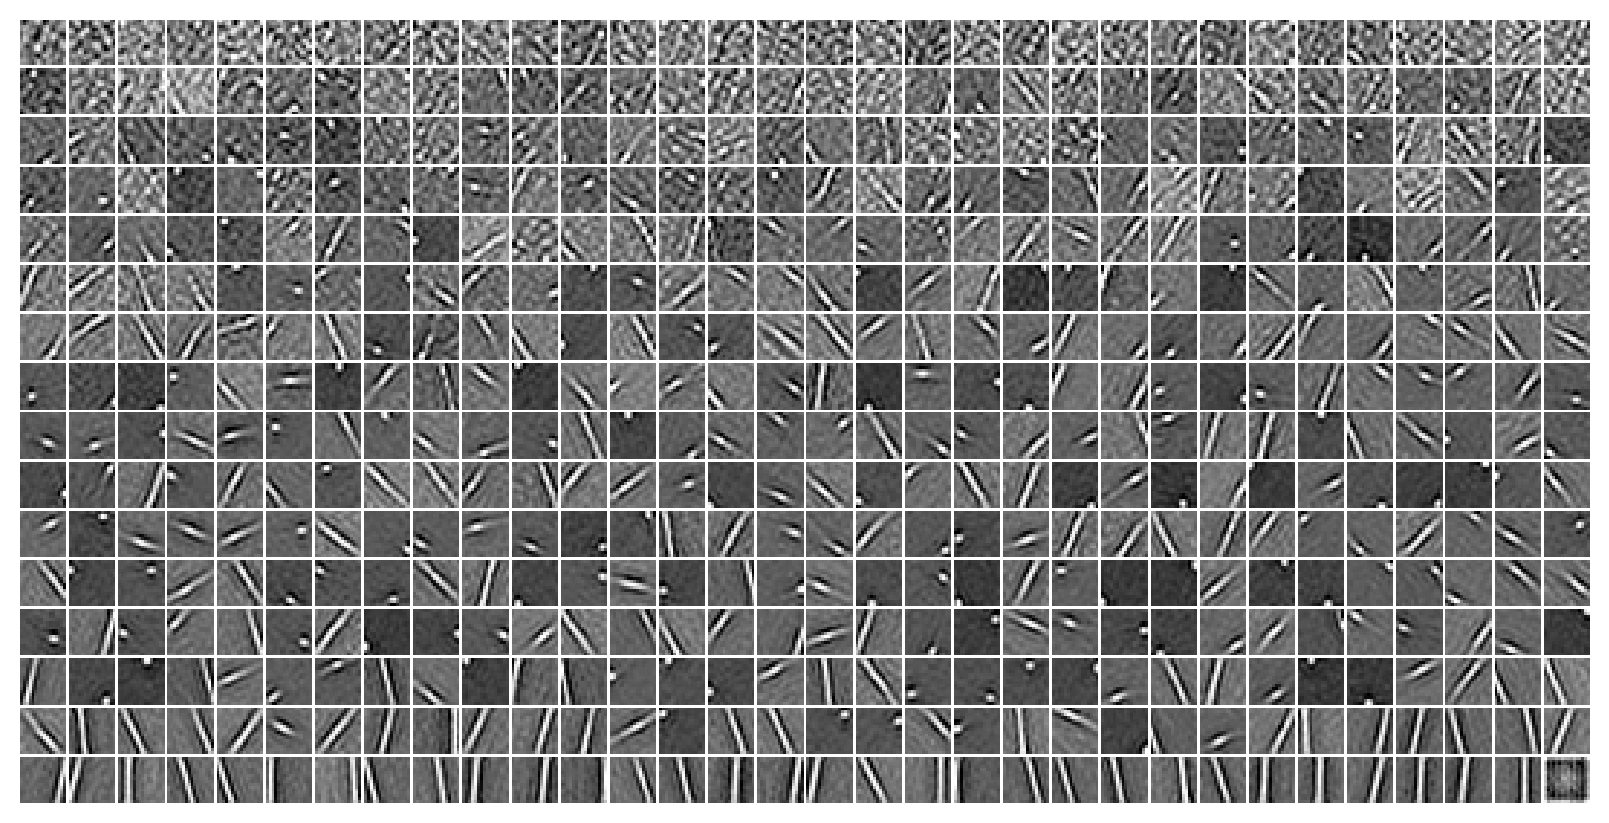

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

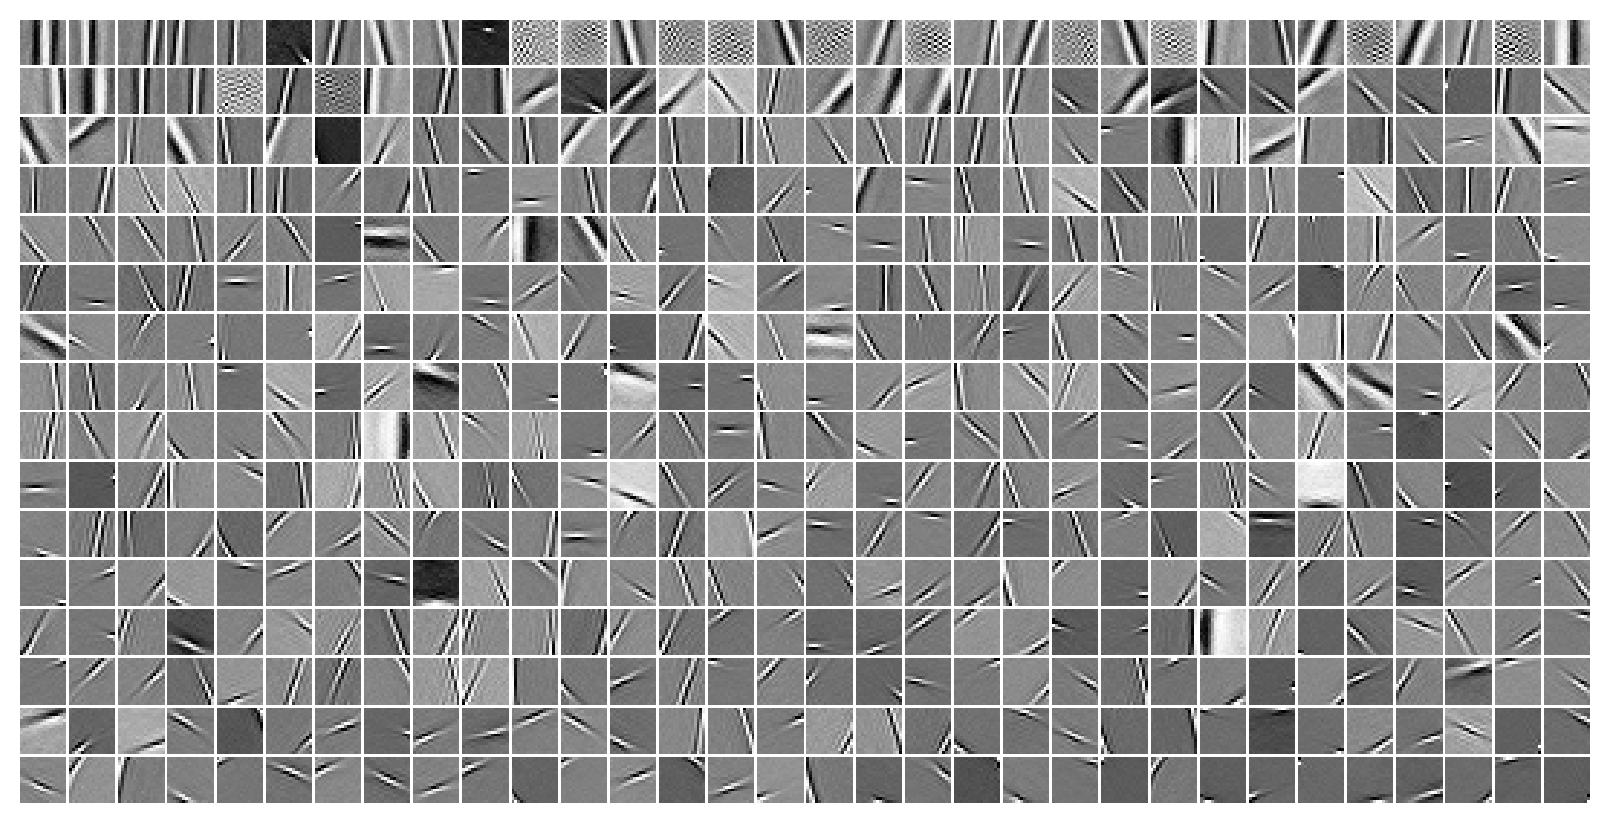

In [11]:
### Was: beta = 32.0

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:44<00:00, 453.76it/s]


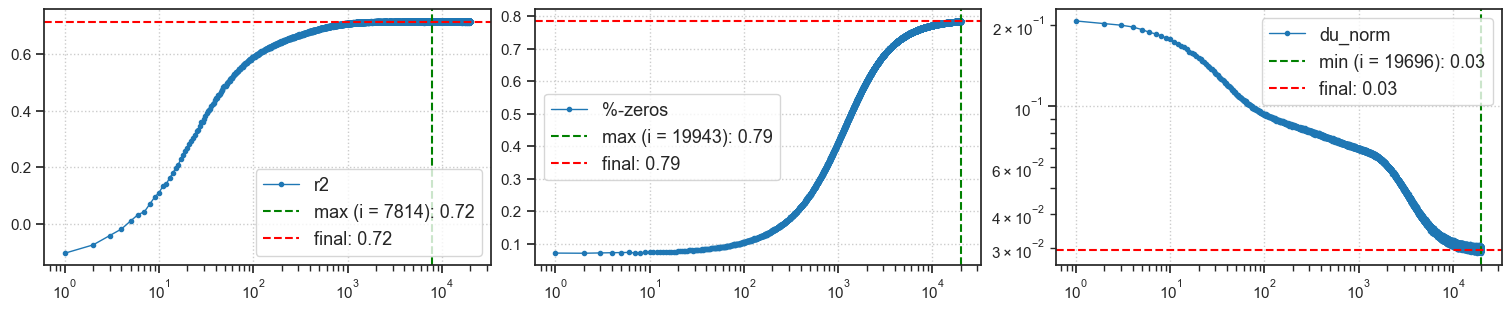

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

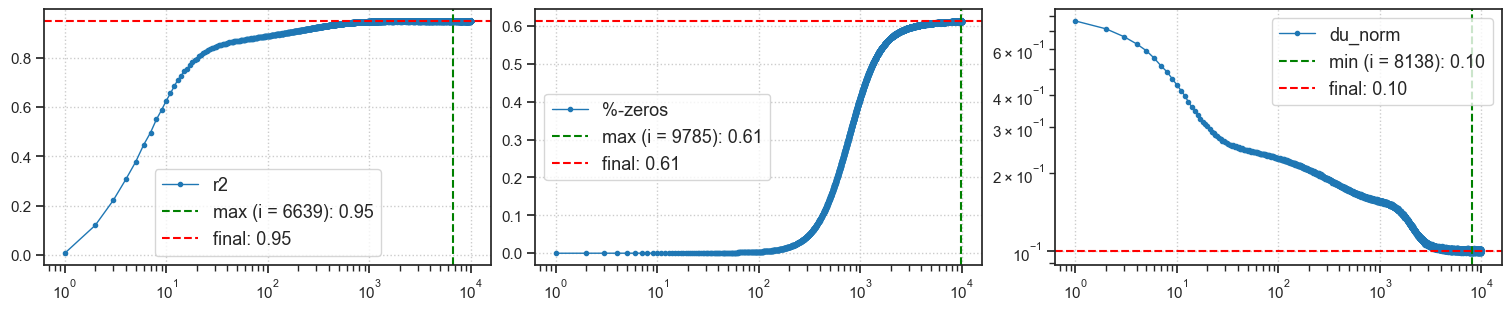

In [54]:
### Was: beta = 32.0

## 32 = 16 § 2  . . .  beta = 32.0

- t_train = 32
- t_tbptt = 16
- beta = 32.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 32
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 32.0

# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 100

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

51500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-32[§16]_b-32_k-[512]_u-10,du-10
b200-ep100-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 100, avg loss: 228.421: 100%|███████| 100/100 [2:25:17<00:00, 87.18s/it]


epoch # 100, avg loss: 262.064: 100%|█████████| 100/100 [48:06<00:00, 28.86s/it]


In [10]:
print(tr.model.layer.n_exp)

tensor([ 40,  47,  57,  68,  80,  93, 107, 119, 131, 142, 151, 158, 164, 169,
        172, 175, 177, 179, 180, 180, 181, 182, 182, 183, 183, 183, 183, 183,
        183, 183, 183, 183], device='cuda:1', dtype=torch.int32)

tensor([25, 35, 47, 61, 73, 81, 86, 88, 89, 89, 89, 89, 89, 89, 89, 89],
       device='cuda:1', dtype=torch.int32)

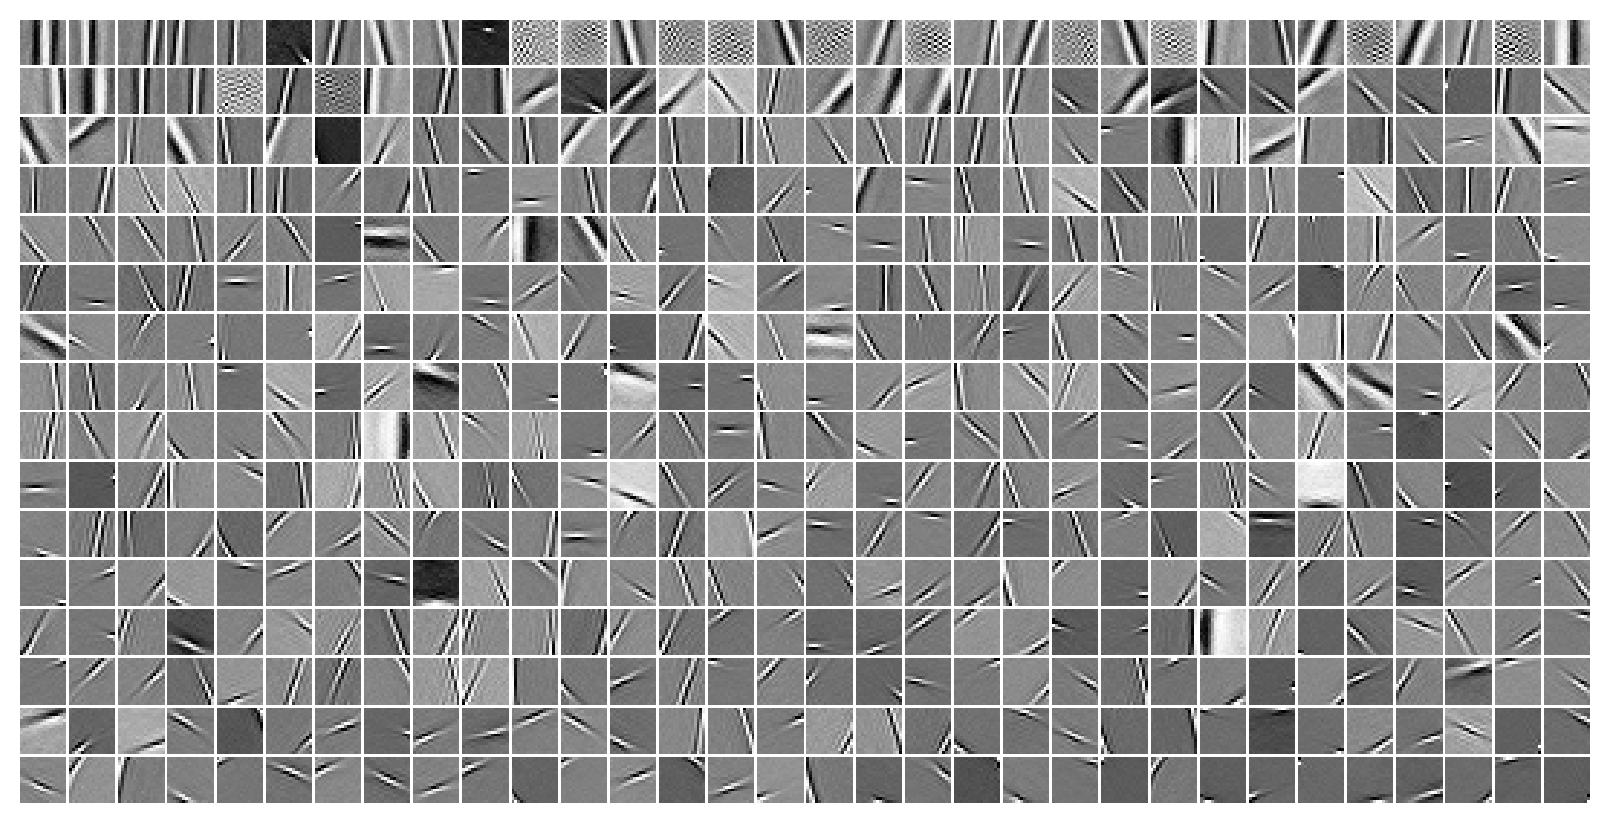

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

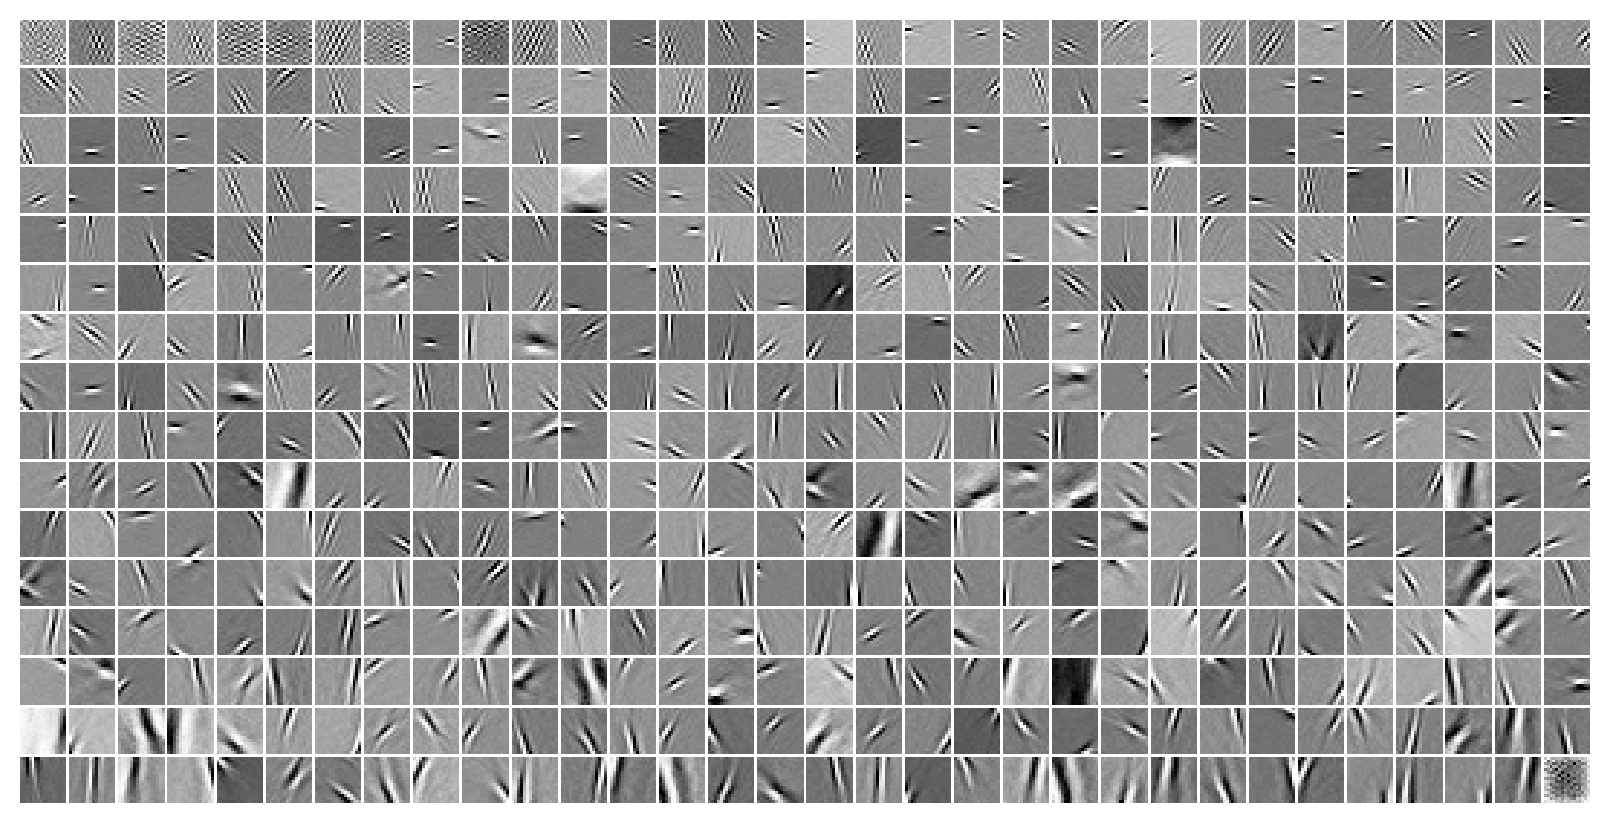

In [9]:
### Was: 16§1, 16.0

In [55]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 506.33it/s]


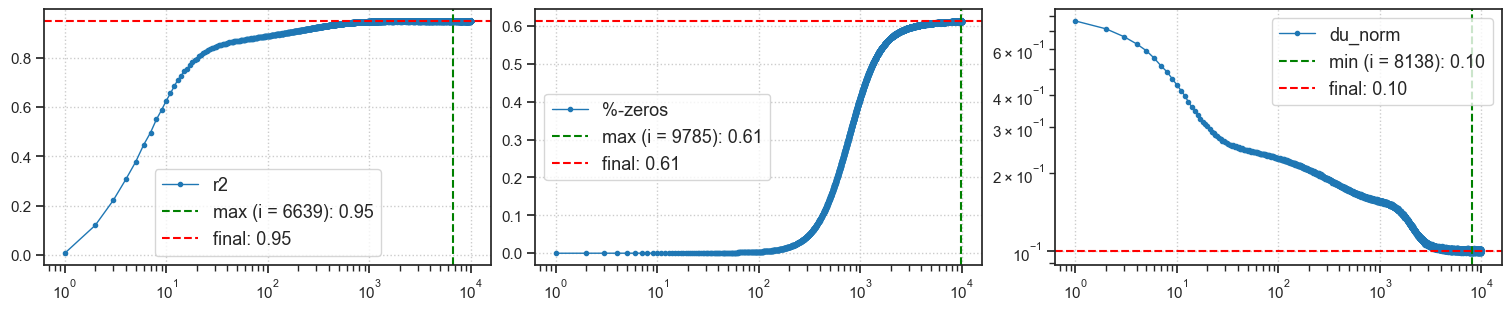

In [54]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

## Standard 16

- t_train = 16
- t_tbptt = 16
- beta = 16.0

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16')

cfg_vae['t_train'] = 16
cfg_vae['beta_outer'] = 16.0
# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 100

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

51500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-16_b-16_k-[512]_u-10,du-10
b200-ep100-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 100, avg loss: 262.064: 100%|█████████| 100/100 [48:06<00:00, 28.86s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([25, 35, 47, 61, 73, 81, 86, 88, 89, 89, 89, 89, 89, 89, 89, 89],
       device='cuda:1', dtype=torch.int32)

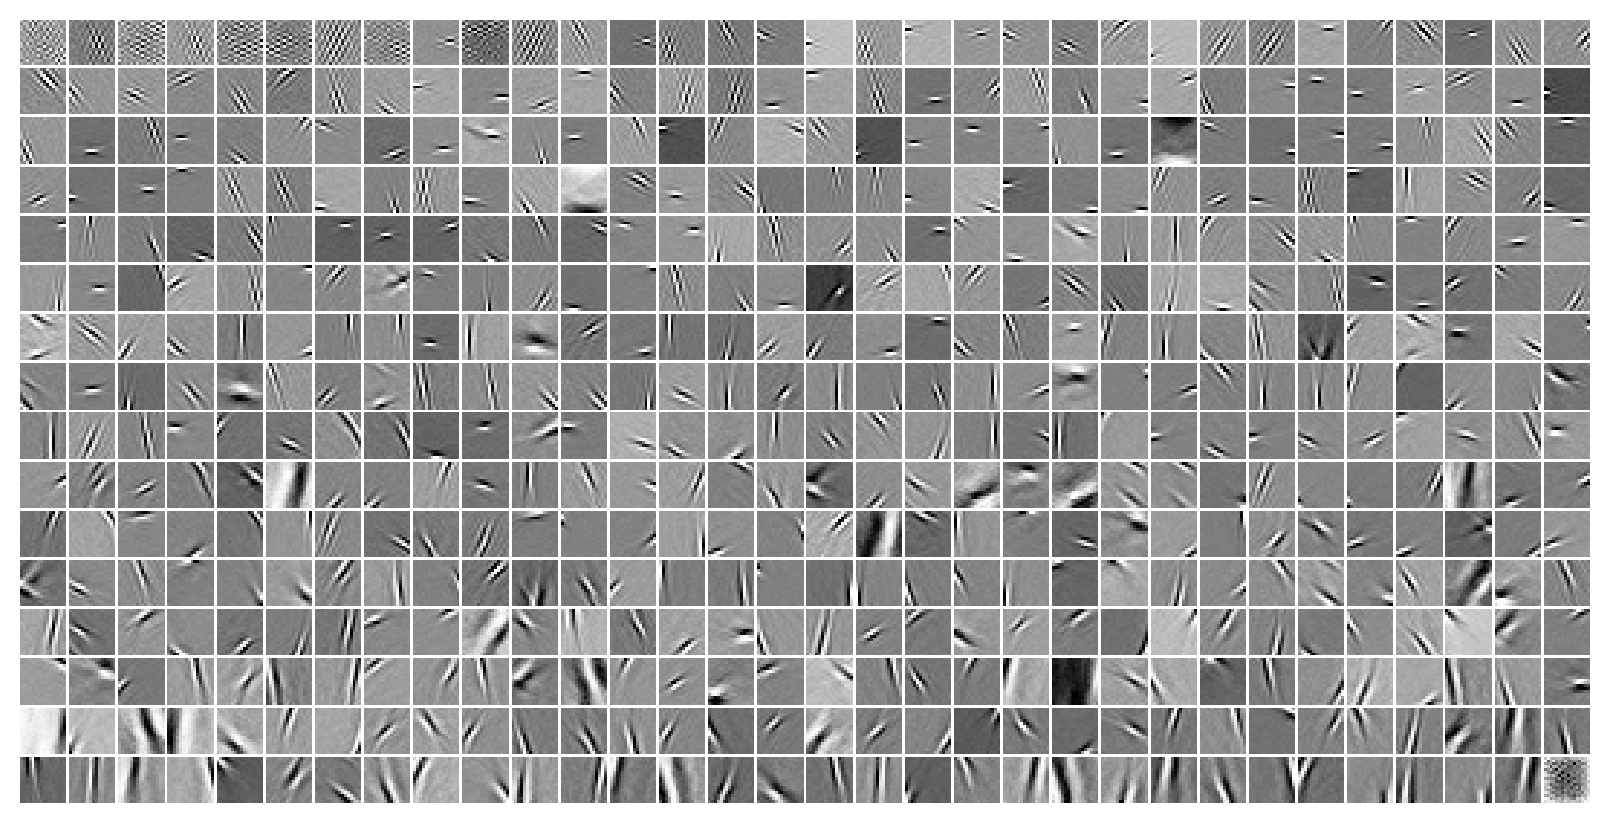

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));